# Paper Experiments Results

This notebook contains the analysis for the paper experiments. It loads data from the `json_export` folder and processes it for the various evaluation sections.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from paper_experiments_results import load_json_exports
import numpy as np
from sklearn.preprocessing import StandardScaler
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor
# Load all dataframes from the json_export folder
dfs = load_json_exports()


Loaded bm_experiments.json into df_bm_experiments
Loaded bm_results.json into df_bm_results
Loaded grid_experiments.json into df_grid_experiments
Loaded grid_results.json into df_grid_results
Loaded models.json into df_models
Loaded solvers.json into df_solvers
Loaded sqlite_sequence.json into df_sqlite_sequence


In [2]:
bm_results = dfs["df_bm_results"]
bm_experiments = dfs["df_bm_experiments"]
models = dfs["df_models"]
solvers = dfs["df_solvers"]

grid_experiments = dfs["df_grid_experiments"]
grid_results = dfs["df_grid_results"]

                          
interesting_models = [
    "M:model_repo/01-23_07-52-10_M_LFalse_FTFalse/checkpoints/policy_module_final.pt)",
    "Job:model_repo/01-23_10-47-36_M_jssp/checkpoints/policy_module_final.pt)+AGV:model_repo/01-23_17-25-04_M_agv/checkpoints/policy_module_final.pt)",
    "Job:model_repo/01-23_10-47-36_M_jssp/checkpoints/policy_module_final.pt)+AGV:model_repo/01-25_20-27-15_M_agv/checkpoints/policy_module_final.pt)",
    "Job:model_repo/01-25_13-50-00_M_jssp/checkpoints/policy_module_final.pt)+AGV:model_repo/01-25_20-27-15_M_agv/checkpoints/policy_module_final.pt)",
    "Job:model_repo/01-25_13-50-00_M_jssp/checkpoints/policy_module_final.pt)+AGV:model_repo/01-23_17-25-04_M_agv/checkpoints/policy_module_final.pt)",
    "Job:model_repo/01-23_10-47-36_M_jssp/checkpoints/policy_module_final.pt)+AGV:model_repo/01-27_15-27-34_M_agv/checkpoints/policy_module_final.pt)",
    "Job:model_repo/01-23_10-47-36_M_jssp/checkpoints/policy_module_final.pt)+AGV:model_repo/01-27_19-08-18_M_agv/checkpoints/policy_module_final.pt)",
    "Job:model_repo/01-23_10-47-36_M_jssp/checkpoints/policy_module_final.pt)+AGV:model_repo/01-28_00-00-24_M_agv/checkpoints/policy_module_final.pt)",
    "Job:model_repo/01-25_13-50-00_M_jssp/checkpoints/policy_module_final.pt)+AGV:model_repo/01-27_15-27-34_M_agv/checkpoints/policy_module_final.pt)",
    "Job:model_repo/01-25_13-50-00_M_jssp/checkpoints/policy_module_final.pt)+AGV:model_repo/01-27_19-08-18_M_agv/checkpoints/policy_module_final.pt)",
    "Job:model_repo/01-25_13-50-00_M_jssp/checkpoints/policy_module_final.pt)+AGV:model_repo/01-28_00-00-24_M_agv/checkpoints/policy_module_final.pt)",
    "Job:model_repo/01-29_07-37-35_M_jssp/checkpoints/policy_module_final.pt)+AGV:model_repo/01-29_07-45-23_M_agv/checkpoints/policy_module_final.pt)",
    "Job:model_repo/01-29_07-37-35_M_jssp/checkpoints/policy_module_final.pt)+AGV:model_repo/01-28_00-00-24_M_agv/checkpoints/policy_module_final.pt)",
    "Job:model_repo/01-29_07-37-35_M_jssp/checkpoints/policy_module_final.pt)+AGV:model_repo/01-27_19-08-18_M_agv/checkpoints/policy_module_final.pt)",
    "Job:model_repo/01-29_07-37-35_M_jssp/checkpoints/policy_module_final.pt)+AGV:model_repo/01-27_15-27-34_M_agv/checkpoints/policy_module_final.pt)",
    "Job:model_repo/01-29_07-37-35_M_jssp/checkpoints/policy_module_final.pt)+AGV:model_repo/01-25_20-27-15_M_agv/checkpoints/policy_module_final.pt)",
    "Job:model_repo/01-29_07-37-35_M_jssp/checkpoints/policy_module_final.pt)+AGV:model_repo/01-23_17-25-04_M_agv/checkpoints/policy_module_final.pt)",
    "Job:model_repo/01-25_13-50-00_M_jssp/checkpoints/policy_module_final.pt)+AGV:model_repo/01-29_07-45-23_M_agv/checkpoints/policy_module_final.pt)",
    "Job:model_repo/01-23_10-47-36_M_jssp/checkpoints/policy_module_final.pt)+AGV:model_repo/01-29_07-45-23_M_agv/checkpoints/policy_module_final.pt)",
    "Job:model_repo/01-29_17-04-34_M_jssp/checkpoints/policy_module_final.pt)+AGV:model_repo/01-29_07-45-23_M_agv/checkpoints/policy_module_final.pt)",
    "Job:model_repo/01-29_17-04-34_M_jssp/checkpoints/policy_module_final.pt)+AGV:model_repo/01-28_00-00-24_M_agv/checkpoints/policy_module_final.pt)",
    "Job:model_repo/01-29_17-04-34_M_jssp/checkpoints/policy_module_final.pt)+AGV:model_repo/01-27_19-08-18_M_agv/checkpoints/policy_module_final.pt)",
    "Job:model_repo/01-29_17-04-34_M_jssp/checkpoints/policy_module_final.pt)+AGV:model_repo/01-27_15-27-34_M_agv/checkpoints/policy_module_final.pt)",
    "Job:model_repo/01-29_17-04-34_M_jssp/checkpoints/policy_module_final.pt)+AGV:model_repo/01-25_20-27-15_M_agv/checkpoints/policy_module_final.pt)",
    "Job:model_repo/01-29_17-04-34_M_jssp/checkpoints/policy_module_final.pt)+AGV:model_repo/01-23_17-25-04_M_agv/checkpoints/policy_module_final.pt)",
    "Job:model_repo/01-23_10-47-36_M_jssp/checkpoints/policy_module_final.pt)+AGV:model_repo/02-10_20-24-20_M_agv/checkpoints/policy_module_final.pt)",
    "Job:model_repo/01-25_13-50-00_M_jssp/checkpoints/policy_module_final.pt)+AGV:model_repo/02-10_20-24-20_M_agv/checkpoints/policy_module_final.pt)",
    "Job:model_repo/01-29_07-37-35_M_jssp/checkpoints/policy_module_final.pt)+AGV:model_repo/02-10_20-24-20_M_agv/checkpoints/policy_module_final.pt)",
    "Job:model_repo/01-29_17-04-34_M_jssp/checkpoints/policy_module_final.pt)+AGV:model_repo/02-10_20-24-20_M_agv/checkpoints/policy_module_final.pt)",
    "Job:model_repo/01-23_10-47-36_M_jssp/checkpoints/policy_module_final.pt)+AGV:model_repo/02-11_09-27-16_M_agv/checkpoints/policy_module_final.pt)",
    "Job:model_repo/01-23_10-47-36_M_jssp/checkpoints/policy_module_final.pt)+AGV:model_repo/02-11_15-23-55_M_agv/checkpoints/policy_module_final.pt)",
    "Job:model_repo/01-23_10-47-36_M_jssp/checkpoints/policy_module_final.pt)+AGV:model_repo/02-11_20-34-26_M_agv/checkpoints/policy_module_final.pt)",
    "Job:model_repo/01-25_13-50-00_M_jssp/checkpoints/policy_module_final.pt)+AGV:model_repo/02-11_09-27-16_M_agv/checkpoints/policy_module_final.pt)",
    "Job:model_repo/01-25_13-50-00_M_jssp/checkpoints/policy_module_final.pt)+AGV:model_repo/02-11_15-23-55_M_agv/checkpoints/policy_module_final.pt)",
    "Job:model_repo/01-25_13-50-00_M_jssp/checkpoints/policy_module_final.pt)+AGV:model_repo/02-11_20-34-26_M_agv/checkpoints/policy_module_final.pt)",
    "Job:model_repo/01-29_07-37-35_M_jssp/checkpoints/policy_module_final.pt)+AGV:model_repo/02-11_09-27-16_M_agv/checkpoints/policy_module_final.pt)",
    "Job:model_repo/01-29_07-37-35_M_jssp/checkpoints/policy_module_final.pt)+AGV:model_repo/02-11_15-23-55_M_agv/checkpoints/policy_module_final.pt)",
    "Job:model_repo/01-29_07-37-35_M_jssp/checkpoints/policy_module_final.pt)+AGV:model_repo/02-11_20-34-26_M_agv/checkpoints/policy_module_final.pt)",
    "Job:model_repo/01-29_17-04-34_M_jssp/checkpoints/policy_module_final.pt)+AGV:model_repo/02-11_09-27-16_M_agv/checkpoints/policy_module_final.pt)",
    "Job:model_repo/01-29_17-04-34_M_jssp/checkpoints/policy_module_final.pt)+AGV:model_repo/02-11_15-23-55_M_agv/checkpoints/policy_module_final.pt)",
    "Job:model_repo/01-29_17-04-34_M_jssp/checkpoints/policy_module_final.pt)+AGV:model_repo/02-11_20-34-26_M_agv/checkpoints/policy_module_final.pt)",
]

coupled = (
    "M:model_repo/01-23_07-52-10_M_LFalse_FTFalse/checkpoints/policy_module_final.pt)"
)


best_decouppled = "Job:model_repo/01-29_17-04-34_M_jssp/checkpoints/policy_module_final.pt)+AGV:model_repo/01-25_20-27-15_M_agv/checkpoints/policy_module_final.pt)"
grid_model_1 = best_decouppled

## 1. Solver Benchmark



In [3]:
def _get_variance_of_agent_to_heuristic( merged_df: pd.DataFrame
) -> pd.DataFrame:
    h_ms_key = "heuristic_min"
    ml_ms_key = "ml_makespan"
    merged_df["makespan_variance_pct"] = (
        (merged_df[ml_ms_key] - merged_df[h_ms_key]) / merged_df[h_ms_key] * 100.0
    )

    merged_df["makespan_dif"] = merged_df[ml_ms_key] - merged_df[h_ms_key]
    merged_df["relative_percentage_increase"] = (
        merged_df["makespan_dif"] / merged_df[h_ms_key]
    ) * -100.0
    return merged_df



def _get_short_name(solver_name: str) -> str:
    """Extract short name from full solver_name/path.

    Parameters
    ----------
    solver_name : str
        Full solver_name from benchmark results

    Returns
    -------
    str
        Shortened solver name for display
    """
    print(f"Getting short name for solver: {solver_name}")
    a = bm_results[bm_results["solver_name"] == solver_name][["job_model_name", "agv_model_name"]].iloc[0]
    job_model_name    = a["job_model_name"]
    agv_model_name    = a["agv_model_name"]
    id_solver_name= solvers[solvers["solver_name"].isin([job_model_name,agv_model_name])][["id", "solver_name"]]
    solver_ids = id_solver_name["id"].values
    solver_id_names = id_solver_name["solver_name"].values
    job_solver_id = id_solver_name[id_solver_name["solver_name"] == job_model_name]["id"].values[0]
    agv_solver_id = id_solver_name[id_solver_name["solver_name"] == agv_model_name]["id"].values[0]
    model_for_job_id_and_agv_id = models[(models["jssp_model_solver_id"]== job_solver_id) & (models["agv_model_solver_id"]== agv_solver_id)]

    model = model_for_job_id_and_agv_id.iloc[0] if not model_for_job_id_and_agv_id.empty else None
    if model is not None:
        info= (
            model["model_type"],
            model["jssp_model_solver_id"],
            model["agv_model_solver_id"],
        )
    else:
        info= (None, None, None)

    return f"{info[0]}_J{info[1]}_A{info[2]}"


def _get_rpi_for_solver_names(df, solver_names):
    """
    Helper function to filter the dataframe for the specified solver names and return the RPI values.
    """
    heuristic_df = df[df["solver_type"] == "heuristic"]
    ml_df = df[df["solver_type"] == "ml"]
    ml_solvers = ml_df["solver_name"].unique().tolist()

    heuristic_agg = (
        heuristic_df.groupby(["bm_experiments_id", "instance_id"])["makespan"]
        .min()
        .reset_index()
    )
    heuristic_agg.rename(columns={"makespan": "heuristic_min"}, inplace=True)

    merged_data = {}
    for ml_solver in solver_names if solver_names is not None else ml_solvers:
        ml_solver_df = ml_df[ml_df["solver_name"] == ml_solver]
        ml_agg = (
            ml_solver_df.groupby(["bm_experiments_id", "instance_id"])[
                "makespan"
            ]
            .mean()
            .reset_index()
        )
        ml_agg.rename(columns={"makespan": "ml_makespan"}, inplace=True)
        merged_df = pd.merge(
            heuristic_agg, ml_agg, on=["bm_experiments_id", "instance_id"]
        )
        merged_df = _get_variance_of_agent_to_heuristic(merged_df)
        merged_df["solver_name"] = ml_solver
        merged_df["shortmodel"] = _get_short_name(ml_solver)

        merged_data[ml_solver] = merged_df
    if not merged_data:
        return None

    combined_merged_df = pd.concat(
        list(merged_data.values()), ignore_index=True
    ).dropna(subset=["relative_percentage_increase"])
    return combined_merged_df



def _get_rpi_for_solver_names_and_heuristic(
        solver_names: list[str] | None = None,
        heuristic_name: str | None = None,
    ):
        df = bm_results

        heuristic_df = df[df["solver_type"] == "heuristic"]
        heuristic_df = heuristic_df[heuristic_df["solver_name"] == heuristic_name]
        ml_df = df[df["solver_type"] == "ml"]
        ml_solvers = ml_df["solver_name"].unique().tolist()
        heuristic_agg = (
            heuristic_df.groupby(["bm_experiments_id", "instance_id"])["makespan"]
            .min()
            .reset_index()
        )
        heuristic_agg.rename(columns={"makespan": "heuristic_min"}, inplace=True)

        merged_data = {}
        for ml_solver in solver_names if solver_names is not None else ml_solvers:
            ml_solver_df = ml_df[ml_df["solver_name"] == ml_solver]
            ml_agg = (
                ml_solver_df.groupby(["bm_experiments_id", "instance_id"])[
                    "makespan"
                ]
                .mean()
                .reset_index()
            )
            ml_agg.rename(columns={"makespan": "ml_makespan"}, inplace=True)
            merged_df = pd.merge(
                heuristic_agg, ml_agg, on=["bm_experiments_id", "instance_id"]
            )
            merged_df = _get_variance_of_agent_to_heuristic(merged_df)
            merged_df["solver_name"] = ml_solver
            merged_df["shortmodel"] = _get_short_name(ml_solver)

            merged_data[ml_solver] = merged_df
        if not merged_data:
            return None

        combined_merged_df = pd.concat(
            list(merged_data.values()), ignore_index=True
        ).dropna(subset=["relative_percentage_increase"])
        return combined_merged_df


Getting short name for solver: M:model_repo/01-23_07-52-10_M_LFalse_FTFalse/checkpoints/policy_module_final.pt)
Getting short name for solver: Job:model_repo/01-23_10-47-36_M_jssp/checkpoints/policy_module_final.pt)+AGV:model_repo/01-23_17-25-04_M_agv/checkpoints/policy_module_final.pt)
Getting short name for solver: Job:model_repo/01-23_10-47-36_M_jssp/checkpoints/policy_module_final.pt)+AGV:model_repo/01-25_20-27-15_M_agv/checkpoints/policy_module_final.pt)
Getting short name for solver: Job:model_repo/01-25_13-50-00_M_jssp/checkpoints/policy_module_final.pt)+AGV:model_repo/01-25_20-27-15_M_agv/checkpoints/policy_module_final.pt)
Getting short name for solver: Job:model_repo/01-25_13-50-00_M_jssp/checkpoints/policy_module_final.pt)+AGV:model_repo/01-23_17-25-04_M_agv/checkpoints/policy_module_final.pt)
Getting short name for solver: Job:model_repo/01-23_10-47-36_M_jssp/checkpoints/policy_module_final.pt)+AGV:model_repo/01-27_15-27-34_M_agv/checkpoints/policy_module_final.pt)
Getting 

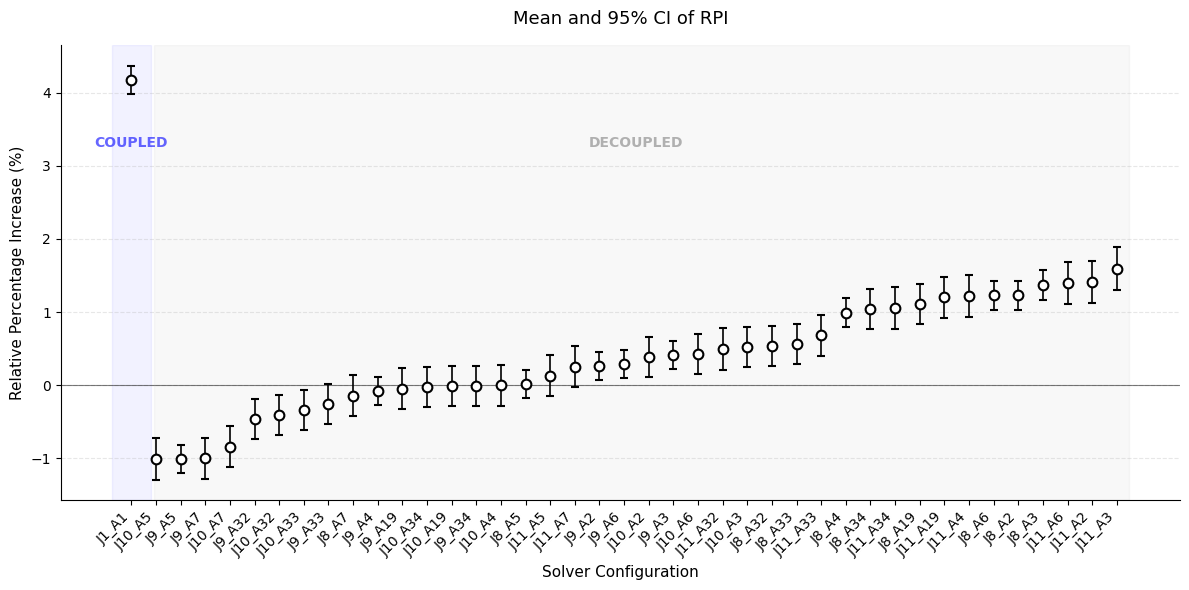

           shortmodel      mean       std  count      ci_m  is_coupled  \
0       coupled_J1_A1  5.336792  6.682242   4800  0.189042        True   
8    decoupled_J10_A5  0.195829  9.837877   4800  0.278315       False   
38    decoupled_J9_A5  0.203112  6.661464   4800  0.188454       False   
40    decoupled_J9_A7  0.206729  9.752724   4800  0.275906       False   
10   decoupled_J10_A7  0.362610  9.788410   4800  0.276916       False   
34   decoupled_J9_A32  0.740990  9.637633   4800  0.272650       False   
4   decoupled_J10_A32  0.797623  9.649328   4800  0.272981       False   
5   decoupled_J10_A33  0.866118  9.571964   4800  0.270792       False   
35   decoupled_J9_A33  0.948872  9.441569   4800  0.267104       False   
30    decoupled_J8_A7  1.053756  9.671871   4800  0.273619       False   
37    decoupled_J9_A4  1.116411  6.629208   4800  0.187541       False   
31   decoupled_J9_A19  1.149196  9.643942   4800  0.272829       False   
6   decoupled_J10_A34  1.178502  9.567

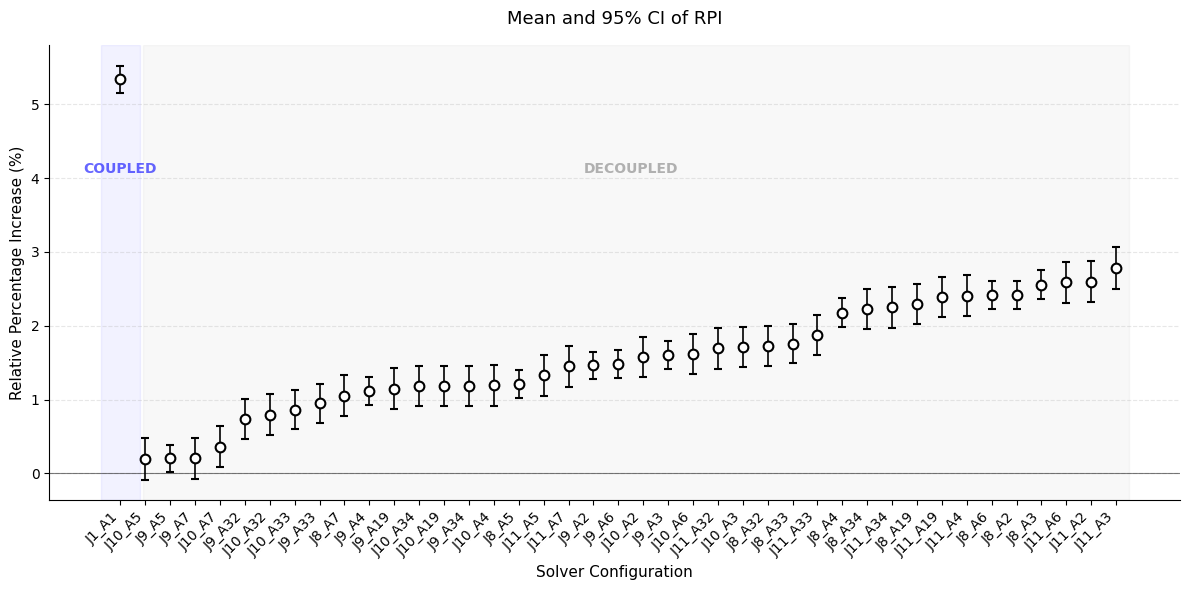

In [4]:
def plot_vertical_dot_paper(combined_merged_df):
        # 1. Statistical Summary
        stats = (
            combined_merged_df.groupby("shortmodel")["relative_percentage_increase"]
            .agg(["mean", "std", "count"])
            .reset_index()
        )
        stats["ci_m"] = 1.96 * (stats["std"] / np.sqrt(stats["count"]))
        stats["is_coupled"] = stats["shortmodel"].str.startswith("coupled")

        # 2. Sort within groups: Coupled first, then Decoupled, both by increasing mean
        stats = stats.sort_values(
            by=["is_coupled", "mean"], ascending=[False, True]
        )
        stats["id_name"] = (
            stats["shortmodel"].str.split("_").str[1]
            + "_"
            + stats["shortmodel"].str.split("_").str[2]
        )
        print(stats)
        # 3. Setup Figure
        plt.figure(figsize=(12, 6))
        x_pos = np.arange(len(stats))

        # 4. Group Background Shading (Vertical)
        coupled_count = stats["is_coupled"].sum()
        plt.axvspan(
            -0.8, coupled_count - 0.2, color="blue", alpha=0.05, label="Coupled"
        )
        plt.axvspan(
            coupled_count - 0.1,
            len(stats) - 0.5,
            color="gray",
            alpha=0.05,
            label="Decoupled",
        )

        # 5. The Dot Plot (Vertical)
        plt.errorbar(
            x_pos,
            stats["mean"],
            yerr=stats["ci_m"],
            fmt="o",
            color="black",
            ecolor="black",
            elinewidth=1.2,
            capsize=3,
            markersize=7,
            mfc="white",
            mew=1.5,
            label="Mean RPI (95% CI)",
        )

        # 6. Styling
        plt.axhline(0, color="black", linestyle="-", linewidth=0.8, alpha=0.5)
        plt.xticks(x_pos, stats["id_name"], rotation=45, ha="right")

        plt.ylabel("Relative Percentage Increase (%)", fontsize=11)
        plt.xlabel("Solver Configuration", fontsize=11)
        plt.title(
            "Mean and 95% CI of RPI",
            fontsize=13,
            pad=15,
        )
        # Text labels for groups
        y_top = plt.gca().get_ylim()[1]
        plt.text(
            coupled_count / 2 - 0.5,
            y_top * 0.7,
            "COUPLED",
            ha="center",
            fontweight="bold",
            color="blue",
            alpha=0.6,
        )
        plt.text(
            coupled_count + (len(stats) - coupled_count) / 2 - 0.5,
            y_top * 0.7,
            "DECOUPLED",
            ha="center",
            fontweight="bold",
            color="gray",
            alpha=0.6,
        )

        sns.despine()
        plt.grid(axis="y", linestyle="--", alpha=0.3)
        plt.tight_layout()
        plt.show()


def plot_rpi(solver_names=None):
    combined_merged_df = _get_rpi_for_solver_names(df=bm_results, solver_names=solver_names)
    heurisitc_defined_merged_df = _get_rpi_for_solver_names_and_heuristic(
        solver_names=solver_names,
        heuristic_name="Job:MOR+AGV:SCTA",
    )
    plot_vertical_dot_paper(combined_merged_df)
    plot_vertical_dot_paper(heurisitc_defined_merged_df)

plot_rpi(solver_names=interesting_models)

## 2. Joint vs Modular (rho)



Getting short name for solver: M:model_repo/01-23_07-52-10_M_LFalse_FTFalse/checkpoints/policy_module_final.pt)
Getting short name for solver: Job:model_repo/01-29_17-04-34_M_jssp/checkpoints/policy_module_final.pt)+AGV:model_repo/01-25_20-27-15_M_agv/checkpoints/policy_module_final.pt)
Short names: J1_A1 vs J11_A3


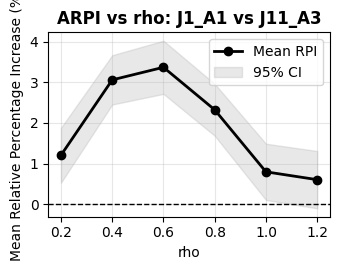

In [5]:
def _get_variance_of_agent_to_agent(merged_df: pd.DataFrame) -> pd.DataFrame:
    h_ms_key = "ml_2_makespan"
    ml_ms_key = "ml_1_makespan"
    merged_df["makespan_variance_pct"] = (
        (merged_df[ml_ms_key] - merged_df[h_ms_key]) / merged_df[h_ms_key] * 100.0
    )

    merged_df["makespan_dif"] = merged_df[ml_ms_key] - merged_df[h_ms_key]
    merged_df["relative_percentage_increase"] = (
        merged_df["makespan_dif"] / merged_df[h_ms_key]
    ) * -100.0
    return merged_df

def _get_rpi_of_agent_vs_agent(model_name_1: str, model_name_2: str):
    df = bm_results
    ml_1_df = df[df["solver_name"] == model_name_1]
    ml_2_df = df[df["solver_name"] == model_name_2]

    # Get heuristic data

    ml_1_df_grid = (
        ml_1_df.groupby(
            [
                "bm_experiments_id",
                "instance_id",
            ]
        )["makespan"]
        .min()
        .reset_index()
        )

    ml_1_df_grid.rename(columns={"makespan": "ml_1_makespan"}, inplace=True)
    # Get ML model data

    ml_2_df_grid = (
        ml_2_df.groupby(
            [
                "bm_experiments_id",
                "instance_id",
            ]
        )["makespan"]
        .min()
        .reset_index()
    )
    ml_2_df_grid.rename(columns={"makespan": "ml_2_makespan"}, inplace=True)
    merged = pd.merge(
        ml_1_df_grid,
        ml_2_df_grid,
        on=[
            "bm_experiments_id",
            "instance_id",
        ],
    )

    merged = _get_variance_of_agent_to_agent(merged)

    return merged


def plot_rpi_for_agent2job_ratio_agent_vs_agent(
        model_name_1: str, model_name_2: str
):
    merged_df = _get_rpi_of_agent_vs_agent(model_name_1, model_name_2)
    short_name_1 = _get_short_name(model_name_1)
    short_name_2 = _get_short_name(model_name_2)
    short_name_1 = short_name_1.split("_")[1] + "_" + short_name_1.split("_")[2]
    short_name_2 = short_name_2.split("_")[1] + "_" + short_name_2.split("_")[2]
    print(f"Short names: {short_name_1} vs {short_name_2}")

    experiment_data = bm_experiments
    experiment_data["agv2job_ratio"] = (
        experiment_data["num_agvs"] / (experiment_data["num_jobs"])
    ).round(1)
    merged_df = merged_df.merge(
        experiment_data[["id", "num_jobs", "num_machines", "agv2job_ratio"]],
        left_on="bm_experiments_id",
        right_on="id",
        how="left",  # optional but usually what you want
    )

    # Aggregate RPI statistics per agv2job_ratio
    summary = (
        merged_df.groupby("agv2job_ratio")["relative_percentage_increase"]
        .agg(["mean", "std"])
        .reset_index()
        .sort_values("agv2job_ratio")
    )

    def plot_95ci_area(summary):
        plt.figure(figsize=(3.5, 2.8))
        plt.plot(
            summary["agv2job_ratio"],
            summary["mean"],
            marker="o",
            linewidth=2,
            label="Mean RPI",
            color="black",
        )
        ci_multiplier = 1.96 / np.sqrt(
            merged_df.groupby("agv2job_ratio")["relative_percentage_increase"]
            .count()
            .values
        )


        plt.fill_between(
            summary["agv2job_ratio"],
            summary["mean"] - ci_multiplier * summary["std"],
            summary["mean"] + ci_multiplier * summary["std"],
            alpha=0.3,
            label="95% CI",
            color="0.7",
        )

        plt.axhline(0, color="black", linestyle="--", linewidth=1)
        plt.xlabel("rho")
        plt.ylabel("Mean Relative Percentage Increase (%)")
        plt.title(
            f"ARPI vs rho: {short_name_1} vs {short_name_2}",
            fontsize=12,
            fontweight="bold",
        )
        plt.grid(True, alpha=0.3)
        plt.legend()
        plt.tight_layout()
        plt.show()
    plot_95ci_area(summary)


plot_rpi_for_agent2job_ratio_agent_vs_agent(
    model_name_1=coupled, model_name_2=best_decouppled
)

## 3. Joint vs Modular (tau & rho)



C:\Users\limz894\AppData\Local\Temp\ipykernel_41572\7145894.py:18: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  ml_1_df["op2transport_ratio"] = _compute_op2transport_ratio(
C:\Users\limz894\AppData\Local\Temp\ipykernel_41572\7145894.py:21: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  ml_2_df["op2transport_ratio"] = _compute_op2transport_ratio(


agv2job_ratio            0.2       0.4       0.6       0.8       1.0       1.2
op2transport_ratio                                                            
-1.0               -0.176676  0.087636  0.955979  4.391478  8.489160  6.847382
-0.9                0.057602  0.639876  1.487355  4.681857  7.797905  4.825173
-0.8               -0.026719  0.600476  1.968612  4.923665  7.333419  4.686343
-0.7               -0.006982  0.179649  1.720996  4.496362  7.627353  4.818891
-0.6                0.083449  0.668193  2.564696  4.947777  6.373926  3.718624
-0.5                0.297796  0.929306  2.777799  4.543993  4.737412  2.637243
-0.4                0.450706  1.258642  3.261617  4.355311  4.539985  2.299027
-0.3                0.703234  1.688639  3.431115  4.246998  3.445787  1.670078
-0.2                0.798048  2.192666  3.587211  3.832547  3.107737  1.775228
-0.1                1.073809  2.673157  3.828492  3.314746  2.389702  1.261965
 0.0                1.362855  3.110688  3.879649  3.

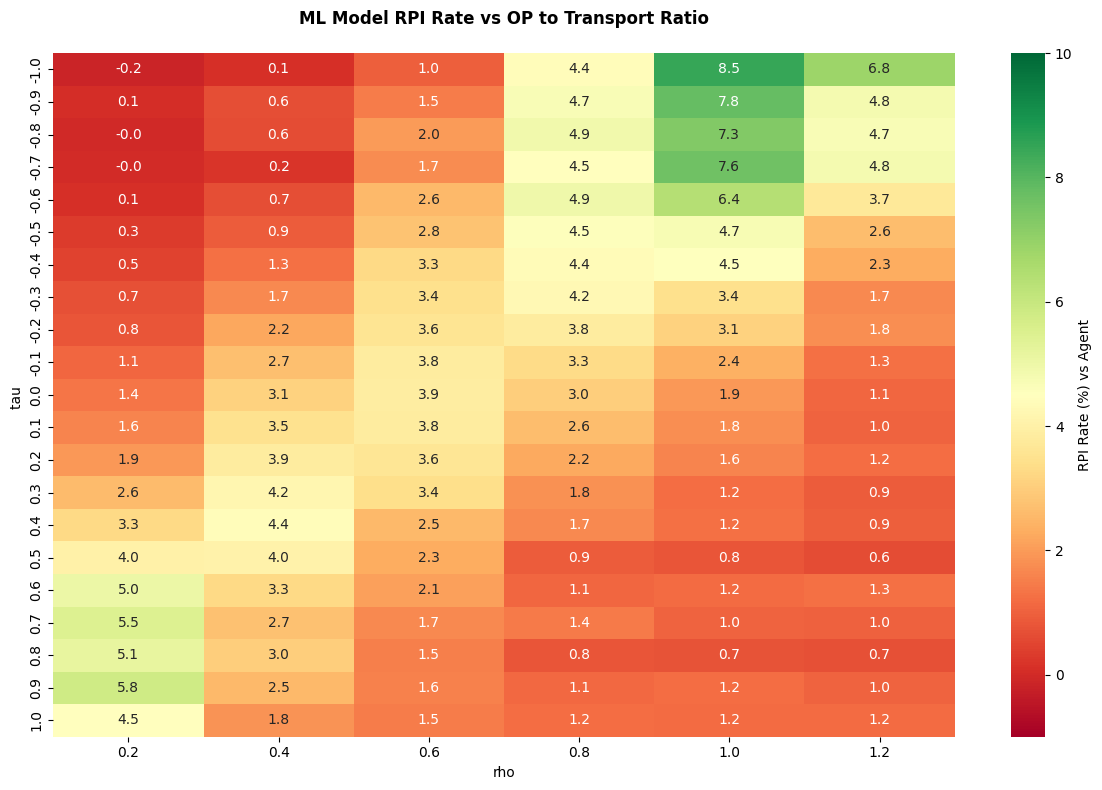

In [6]:
def _compute_op2transport_ratio(min_travel, min_op):
        min_val = 0
        max_val = 100
        op_scaled = (min_op - min_val) / (max_val - min_val)
        tr_scaled = (min_travel - min_val) / (max_val - min_val)
        ratios_norm = op_scaled / (op_scaled + tr_scaled)

        ratios_scaled = 2 * ratios_norm - 1
        return ratios_scaled

def _get_rpi_for_agv2job_ratio_x_op2transport_ratio_for_model_vs_agent(
        ml_model_name_1: str | None = None,
        ml_model_name_2: str | None = None,
    ):
        df = grid_results
        ml_1_df = df[df["solver_name"] == ml_model_name_1]
        ml_2_df = df[df["solver_name"] == ml_model_name_2]
        ml_1_df["op2transport_ratio"] = _compute_op2transport_ratio(
            ml_1_df["min_travel"], ml_1_df["min_op"]
        )
        ml_2_df["op2transport_ratio"] = _compute_op2transport_ratio(
            ml_2_df["min_travel"], ml_2_df["min_op"]
        )

        experiment_df = grid_experiments
        experiment_df["agv2job_ratio"] = (
            experiment_df["num_agvs"] / (experiment_df["num_jobs"])
        ).round(1)

        ml_1_df_grid = (
            ml_1_df.groupby(
                [
                    "grid_experiments_id",
                    "op2transport_ratio",
                    "min_op",
                    "min_travel",
                    "nr_inst",
                ]
            )["makespan"]
            .min()
            .reset_index()
        )

        ml_1_df_grid.rename(columns={"makespan": "ml_1_makespan"}, inplace=True)
        ml_2_df_grid = (
            ml_2_df.groupby(
                [
                    "grid_experiments_id",
                    "op2transport_ratio",
                    "min_op",
                    "min_travel",
                    "nr_inst",
                ]
            )["makespan"]
            .min()
            .reset_index()
        )
        ml_2_df_grid.rename(columns={"makespan": "ml_2_makespan"}, inplace=True)

        merged = pd.merge(
            ml_1_df_grid,
            ml_2_df_grid,
            on=[
                "grid_experiments_id",
                "op2transport_ratio",
                "min_op",
                "min_travel",
                "nr_inst",
            ],
        )

        merged["win"] = merged["ml_1_makespan"] < merged["ml_2_makespan"]
        merged = _get_variance_of_agent_to_agent(merged)
        merged = merged.merge(
            experiment_df[["id", "agv2job_ratio"]],
            how="left",  
            left_on="grid_experiments_id",  
            right_on="id",  
        )

        merged["agv2job_ratio"] = merged["agv2job_ratio"].round(2)
        return merged

def _get_rpi_model_pivot_for_agv2job_ratio_x_op2transport_ratio_for_model_vs_agent(
        ml_model_name_1: str | None = None,
        ml_model_name_2: str | None = None,
    ):
        merged = (
            _get_rpi_for_agv2job_ratio_x_op2transport_ratio_for_model_vs_agent(
                ml_model_name_1=ml_model_name_1,
                ml_model_name_2=ml_model_name_2,
            )
        )
        merged["op2transport_ratio"] = merged["op2transport_ratio"].round(1)
        aggregated_df = (
            merged.groupby(["agv2job_ratio", "op2transport_ratio"])
            .agg(
                win_count=("relative_percentage_increase", "sum"),  
                total_count=(
                    "relative_percentage_increase",
                    "count",
                ),  
            )
            .reset_index()
        )

        aggregated_df["rpi_rate"] = (
            aggregated_df["win_count"] / aggregated_df["total_count"]
        )
        return aggregated_df


def plot_rpi_per_agv2job_ratio_x_op2transport_ratio_for_agent_vs_agent(
        ml_model_name_1: str | None = None,
        ml_model_name_2: str | None = None,
        figsize: tuple[int, int] = (12, 8),
    ):
        """ """
        plot_df = _get_rpi_model_pivot_for_agv2job_ratio_x_op2transport_ratio_for_model_vs_agent(
            ml_model_name_1=ml_model_name_1,
            ml_model_name_2=ml_model_name_2,
        )

        pivot_table = plot_df.pivot_table(
            index="op2transport_ratio",
            columns="agv2job_ratio",
            values="rpi_rate",
            aggfunc="mean",
        )
        print(pivot_table)
        plt.figure(figsize=figsize)
        sns.heatmap(
            pivot_table,
            annot=True,
            fmt=".1f",
            cmap="RdYlGn",
            cbar_kws={"label": "RPI Rate (%) vs Agent"},
            vmin=-1,
            vmax=10,
        )

        plt.title(
            "ML Model RPI Rate vs OP to Transport Ratio\n",
            fontsize=12,
            fontweight="bold",
        )
        plt.xlabel("rho")
        plt.ylabel("tau ")
        plt.tight_layout()
        plt.show()

plot_rpi_per_agv2job_ratio_x_op2transport_ratio_for_agent_vs_agent(
    ml_model_name_2=grid_model_1,
    ml_model_name_1=coupled,
)

## 4. OLS Regression Analysis

In [7]:
def compute_regression_significance_aggregated(
        ml_model_name_1: str | None = None,
        ml_model_name_2: str | None = None,
        figsize: tuple[int, int] = (12, 8),
    ):
        """ """
        df = _get_rpi_model_pivot_for_agv2job_ratio_x_op2transport_ratio_for_model_vs_agent(
            ml_model_name_1=ml_model_name_1,
            ml_model_name_2=ml_model_name_2,
        )


        def _get_features_with_repl(df):
 
            df["interaction"] = df["agv2job_ratio"] * df["op2transport_ratio"]

            df["bn"] = -np.where(
                df["op2transport_ratio"] <= 0, 0, df["op2transport_ratio"]
            ) + (-df["agv2job_ratio"] + 1)
            df["all_bn"] = np.abs(df["bn"])
            df["balance"] = (df["all_bn"] - 1) * 1
            df["balance_sq"] = df["balance"] ** 2

            df["agv_s"] = (df["agv2job_ratio"] - 1) * (df["op2transport_ratio"])
            df["agv_rev"] = (df["agv2job_ratio"] - 1) * -1

            df["int_agv_rev*-1"] = (df["agv_rev"] * df["op2transport_ratio"]) * -1

            features = [

                "balance_sq",
                "interaction",
                "int_agv_rev*-1",
  
            ]
            return df, features


        def compute_standardized_regression(df):
            # df, features = _get_interaction_features(df)
            # df, features = _get_features(df)
            df, features = _get_features_with_repl(df)
            corr_matrix = df[features].corr()
            print("Correlation Matrix:\n", corr_matrix)

            # 2. Scale the features (Z-score)
            scaler = StandardScaler()
            scaled_values = scaler.fit_transform(df[features])
            vif_data = pd.DataFrame()
            vif_data["feature"] = features

            vif_data["VIF"] = [
                variance_inflation_factor(scaled_values, i)
                for i in range(scaled_values.shape[1])
            ]

            print(vif_data)
            df_scaled = pd.DataFrame(scaled_values, columns=features)
            agv_mean, agv_std = scaler.mean_[0], scaler.scale_[0]
            op_mean, op_std = scaler.mean_[1], scaler.scale_[1]
            X = sm.add_constant(df_scaled)

            for feature in features:
                print(f"\n--- Independent Analysis for: {feature} ---")

                # 1. Prepare X and y
                X_single = df[[feature]]
                X_single = sm.add_constant(X_single)  # Don't forget the intercept!
                y = df["rpi_rate"].values

                # 2. Run the simple model
                model_single = sm.OLS(y, X_single).fit()

                # 3. Report the core findings
                print(f"Coefficient: {model_single.params[feature]:.4f}")
                print(f"P-value: {model_single.pvalues[feature]:.4f}")
                print(f"R-squared: {model_single.rsquared:.4f}")

            # 1. Prepare X and y
            print("\n--- Independent Analysis for: interaction", "int_agv_rev*-1 ---")
            X_single = df[["interaction", "int_agv_rev*-1"]]
            X_single = sm.add_constant(X_single)  # Don't forget the intercept!
            y = df["rpi_rate"].values

            # 2. Run the simple model
            model_single = sm.OLS(y, X_single).fit()
            print(model_single.summary())


            y = df["rpi_rate"].values  # Target remains in original units (%)

            model_scaled = sm.OLS(y, X).fit()

            print(" === Standardized Regression Results === ")
            print(model_scaled.summary())
            return model_scaled, None, scaler

        def predict_with_standardized_interaction_features(model, df, scaler):
            # df, features = _get_interaction_features(df)
            # df, features = _get_features(df)
            df, features = _get_features_with_repl(df)
            # 2. Scale the features (Z-score)
            # scaler = StandardScaler()
            scaled_values = scaler.transform(df[features])
            df_scaled = pd.DataFrame(scaled_values, columns=features)
            X = sm.add_constant(df_scaled)
            # 4. Fit the model
            df["rpi_predicted"] = model.predict(X)
            return df




    # compute_relative_percentage_increase_single_features(df)
        model, importance, scaler = compute_standardized_regression(df)
        df_with_predictions = predict_with_standardized_interaction_features(
            model, df, scaler
        )

compute_regression_significance_aggregated(
        ml_model_name_2=grid_model_1,
        ml_model_name_1=coupled,
    )

Correlation Matrix:
                 balance_sq  interaction  int_agv_rev*-1
balance_sq        1.000000    -0.418502       -0.432994
interaction      -0.418502     1.000000       -0.263589
int_agv_rev*-1   -0.432994    -0.263589        1.000000
          feature       VIF
0      balance_sq  1.969923
1     interaction  1.720105
2  int_agv_rev*-1  1.746230

--- Independent Analysis for: balance_sq ---
Coefficient: 4.0637
P-value: 0.0000
R-squared: 0.4924

--- Independent Analysis for: interaction ---
Coefficient: -2.0511
P-value: 0.0000
R-squared: 0.2800

--- Independent Analysis for: int_agv_rev*-1 ---
Coefficient: -2.8341
P-value: 0.0000
R-squared: 0.1821

--- Independent Analysis for: interaction int_agv_rev*-1 ---
                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.625
Model:                            OLS   Adj. R-squared:                  0.619
Method:                 Least Squares

C:\Users\limz894\AppData\Local\Temp\ipykernel_41572\7145894.py:18: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  ml_1_df["op2transport_ratio"] = _compute_op2transport_ratio(
C:\Users\limz894\AppData\Local\Temp\ipykernel_41572\7145894.py:21: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  ml_2_df["op2transport_ratio"] = _compute_op2transport_ratio(
